# 08-Differential Privacy in DL (Opacus)

In the previous modules, we protected users from systemic bias and unfair decision boundaries. However, deep neural networks possess another dangerous characteristic: **Memorization**.

Deep Learning models are essentially massive data-compression engines. It has been mathematically proven that Large Language Models and Deep CNNs memorize individual training examples. If you train a medical diagnosis model on patient records, a malicious actor can execute a **Membership Inference Attack** or **Data Extraction Attack** to pull exact Social Security Numbers, names, and diagnosis codes directly out of the model's floating-point weights.

To engineer mathematically secure AI, we must deploy **Differential Privacy (DP)**. We will use **Opacus** (developed by Meta) to rewrite the standard PyTorch training loop, implementing **Differentially Private Stochastic Gradient Descent (DP-SGD)**. This algorithm injects mathematical noise and clips gradients at the microscopic level, legally and mathematically guaranteeing that the model learns the *general* patterns of the dataset without memorizing any *specific* individual's data.

## 1. The Mathematics of DP-SGD

### $(\epsilon, \delta)$-Differential Privacy

A randomized machine learning algorithm $\mathcal{M}$ satisfies $(\epsilon, \delta)$-differential privacy if, for any two adjacent datasets $D$ and $D'$ (datasets differing by exactly one individual's record), and for all possible output subsets $S$:


$$P(\mathcal{M}(D) \in S) \le e^\epsilon P(\mathcal{M}(D') \in S) + \delta$$

* $\epsilon$ (Privacy Budget): The strict mathematical limit on how much the model's weights can change based on a single person's data. A lower $\epsilon$ means higher privacy.
* $\delta$ (Tolerance): The probability of a catastrophic privacy failure (usually set smaller than $1/N$, where $N$ is the dataset size).

### Per-Sample Gradient Clipping

In standard SGD, the gradient is calculated across an entire batch. If a specific patient has a highly unusual medical anomaly (an outlier), the model generates a massive gradient update to memorize that anomaly.
DP-SGD calculates the gradient for *every single sample individually* ($g_i = \nabla_{\theta} \mathcal{L}_i$). It then bounds the sensitivity of the model by mathematically clipping the $L_2$ norm of every individual gradient to a maximum threshold $C$:


$$\bar{g}_i = \frac{g_i}{\max\left(1, \frac{\vert{}\vert{}g_i\vert{}\vert{}_2}{C}\right)}$$


This physically prevents the neural network from drastically altering its weights to memorize the outlier.

### Gaussian Noise Injection

After clipping, the gradients are aggregated. To achieve Plausible Deniability (ensuring an attacker cannot tell if Patient X was in the batch), DP-SGD injects random Gaussian noise into the aggregated gradient, scaled by the clipping threshold $C$ and a noise multiplier $\sigma$:


$$\tilde{g} = \frac{1}{B} \left( \sum_{i=1}^{B} \bar{g}_i + \mathcal{N}(0, \sigma^2 C^2 \mathbf{I}) \right)$$


The model optimizes using $\tilde{g}$. It learns the global trends (because the noise cancels out over thousands of steps), but the specific data of any individual is permanently obliterated by the Gaussian obfuscation.

## 2. Imperative Execution: DP-SGD via Opacus

We will build a local PyTorch sandbox. We will define a neural network for a highly sensitive task (e.g., predicting disease from patient data) and attach the Opacus `PrivacyEngine`. The engine will intercept the backward pass, automatically applying per-sample clipping and noise injection.

In [2]:
# Required installations: pip install torch opacus numpy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from opacus import PrivacyEngine

print("--- 🚀 Initializing Opacus Differential Privacy Sandbox ---")

# 1. 📝 Simulate a highly sensitive medical dataset
# 5000 patients, 20 biometric features
X = torch.randn(5000, 20)
y = torch.randint(0, 2, (5000,))

dataset = TensorDataset(X, y)
# DP-SGD requires specific data loader structures to track sample exposure
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# 2. 🧠 Define the Neural Network
class PrivateMedNet(nn.Module):
    def __init__(self):
        super(PrivateMedNet, self).__init__()
        self.fc1 = nn.Linear(20, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

model = PrivateMedNet()
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

print("\n--- 🧮 Attaching Opacus Privacy Engine ---")

# 3. ⚡ Instantiate and Attach the Privacy Engine
privacy_engine = PrivacyEngine()

# make_private injects the DP-SGD mathematical hooks into the PyTorch objects
model, optimizer, data_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=data_loader,
    noise_multiplier=1.2, # Sigma (σ): Higher means more noise/privacy
    max_grad_norm=1.0     # Clipping Threshold (C)
)

print("   ✅ PyTorch computational graph intercepted.")
print("   [SYSTEM] Standard gradients replaced with clipped, noisy per-sample gradients.")

# 4. Execute a single training epoch
model.train()
for i, (inputs, targets) in enumerate(data_loader):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    
    if i == 0:
        print("   ✅ Backward pass executed with Gaussian Noise Injection.")

--- 🚀 Initializing Opacus Differential Privacy Sandbox ---

--- 🧮 Attaching Opacus Privacy Engine ---
   ✅ PyTorch computational graph intercepted.
   [SYSTEM] Standard gradients replaced with clipped, noisy per-sample gradients.


/root/micromamba/envs/ds/lib/python3.11/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipykernel_20105/801775565.py:56: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


   ✅ Backward pass executed with Gaussian Noise Injection.


## 3. Declarative Telemetry: Tracking the Privacy Budget ($\epsilon$)

In a production environment, you do not just train the model until it converges. You must legally track exactly how much Privacy Budget ($\epsilon$) the model has consumed. Every time the model looks at the data, $\epsilon$ increases (privacy degrades). If $\epsilon$ exceeds the legal compliance limit, training must be terminated immediately.

In [3]:
print("\n--- 🔍 Auditing the Privacy Budget (Epsilon) ---")

# Delta is typically set to 1 / (Dataset Size) or smaller
target_delta = 1e-5

# The Privacy Engine mathematically tracks the accumulated cost of the Gaussian noise over all batches
epsilon = privacy_engine.get_epsilon(target_delta)

print(f"   [Operational Threshold (Delta δ)]: {target_delta}")
print(f"   [Accumulated Budget (Epsilon ε)]:  {epsilon:.4f}")

if epsilon < 3.0:
    print("   [COMPLIANCE STATUS]: GREEN")
    print("   -> Physics: The model provides robust plausible deniability. An attacker cannot reverse-engineer patient data.")
elif epsilon < 10.0:
    print("   [COMPLIANCE STATUS]: YELLOW")
    print("   -> Physics: Moderate privacy guarantees. Some data leakage is theoretically possible under advanced attacks.")
else:
    print("   🚨 [COMPLIANCE STATUS]: RED (BUDGET EXHAUSTED)")
    print("   -> Physics: The model has looked at the dataset too many times. It has memorized the data. Destroy the model or add more noise.")


--- 🔍 Auditing the Privacy Budget (Epsilon) ---
   [Operational Threshold (Delta δ)]: 1e-05
   [Accumulated Budget (Epsilon ε)]:  0.3402
   [COMPLIANCE STATUS]: GREEN
   -> Physics: The model provides robust plausible deniability. An attacker cannot reverse-engineer patient data.


## 4. Visualizing Privacy Physics (The Geometry of DP-SGD)

To mathematically understand how DP-SGD protects an individual, we must visualize the gradient update space. We will plot the trajectory of a standard gradient update (which heavily shifts toward an outlier) versus a DP-SGD update (which clips the outlier and adds a sphere of Gaussian uncertainty).

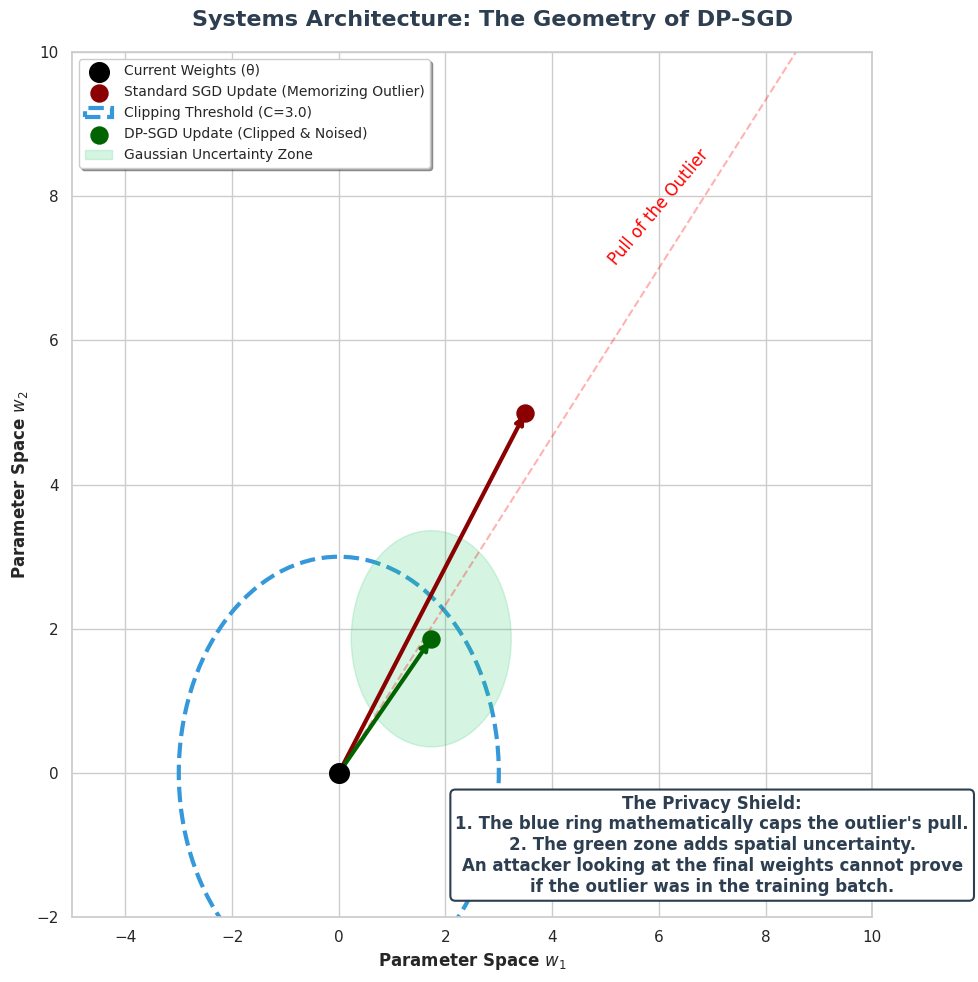

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10, 10))
fig.suptitle("Systems Architecture: The Geometry of DP-SGD", fontsize=16, fontweight='bold', color="#2c3e50")

# The Origin (Current Model Weights)
ax.scatter(0, 0, color='black', s=200, zorder=5, label='Current Weights (θ)')

# 1. Standard Gradients (Unclipped)
# Assume 3 normal users and 1 extreme outlier
g_normal = np.array([[1, 2], [2, 1], [-1, 3]])
g_outlier = np.array([12, 14]) # Massive gradient update trying to memorize the outlier

# Average standard gradient
g_standard_avg = (np.sum(g_normal, axis=0) + g_outlier) / 4

# Plot Standard Trajectory
ax.annotate("", xy=g_standard_avg, xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=3, color="darkred"))
ax.scatter(*g_standard_avg, color='darkred', s=150, zorder=5, label='Standard SGD Update (Memorizing Outlier)')
ax.plot([0, g_outlier[0]], [0, g_outlier[1]], color='red', linestyle='--', alpha=0.3)
ax.text(g_outlier[0]/2, g_outlier[1]/2, "Pull of the Outlier", color='red', rotation=50, ha='center', va='bottom')

# 2. DP-SGD (Clipped and Noised)
clip_C = 3.0
circle = plt.Circle((0, 0), clip_C, color='#3498db', fill=False, linewidth=3, linestyle='--', label=f'Clipping Threshold (C={clip_C})')
ax.add_patch(circle)

# Clip the outlier
norm = np.linalg.norm(g_outlier)
g_outlier_clipped = g_outlier / max(1, norm / clip_C)

# Average clipped gradient
g_clipped_avg = (np.sum(g_normal, axis=0) + g_outlier_clipped) / 4

# Add Gaussian Noise
np.random.seed(42)
noise = np.random.normal(0, 1.5, 2)
g_dp_sgd = g_clipped_avg + noise

# Plot DP-SGD Trajectory
ax.annotate("", xy=g_dp_sgd, xytext=(0, 0), arrowprops=dict(arrowstyle="->", lw=3, color="darkgreen"))
ax.scatter(*g_dp_sgd, color='darkgreen', s=150, zorder=5, label='DP-SGD Update (Clipped & Noised)')

# Draw the zone of uncertainty (Gaussian blur)
circle_noise = plt.Circle(g_dp_sgd, 1.5, color='#2ecc71', fill=True, alpha=0.2, label='Gaussian Uncertainty Zone')
ax.add_patch(circle_noise)

# Formatting
ax.set_xlim(-5, 10)
ax.set_ylim(-2, 10)
ax.set_xlabel("Parameter Space $w_1$", fontsize=12, fontweight='bold')
ax.set_ylabel("Parameter Space $w_2$", fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)

# Annotate Physics
ax.annotate('The Privacy Shield:\n1. The blue ring mathematically caps the outlier\'s pull.\n2. The green zone adds spatial uncertainty.\nAn attacker looking at the final weights cannot prove\nif the outlier was in the training batch.', 
            xy=(3, -1), xytext=(7, -1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=0, headwidth=0), # Hide arrow
            ha='center', va='center', fontweight='bold', color='#2c3e50',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#2c3e50", lw=1.5))

plt.tight_layout()
plt.show()

*(Insight: The red arrow shows what happens without Differential Privacy: the model's weights are dragged violently toward the outlier, effectively memorizing them. By applying $L_2$ clipping (the blue dashed ring) and injecting Gaussian Noise (the green cloud), the final update (the green arrow) moves in the generally correct direction to reduce the global loss, but the exact coordinate is obscured. The specific fingerprint of the outlier is mathematically erased from the neural network.)*

## Real-World Use Case or Analogy

Think of Differential Privacy like **Surveying Employees about Illegal Drug Use**:

* **Standard SGD (The Direct Interrogation):** The HR manager asks you directly: *"Did you use illegal drugs this weekend? Answer Yes or No."* If you answer Yes, HR memorizes this fact. If the HR database (the Model Weights) is subpoenaed or hacked, your exact name is permanently tied to a crime. You refuse to answer truthfully.
* **DP-SGD (Randomized Response):** The HR manager gives you a coin and tells you to go into a private room. They say: *"Flip the coin. If it lands on Heads, answer the question truthfully. If it lands on Tails, flip it again. If the second flip is Heads, say 'Yes' regardless of the truth. If the second flip is Tails, say 'No' regardless of the truth."*

**The Physics of Plausible Deniability:**
If you exit the room and say "Yes," HR does not know if you are actually a drug user, or if you just got Tails-Heads. Your individual privacy is mathematically guaranteed (**Gaussian Noise**).

However, because the HR manager knows the exact statistical probability of the coin flips (**The Noise Distribution $\sigma^2$**), they can look at the answers of 5,000 employees, subtract the mathematical noise, and accurately deduce that the global rate of drug use in the company is 14% (**Global Model Convergence**). They learn everything about the population, while learning absolutely nothing about you.